Import the neccessary libraries

In [23]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

Data Acquisition and Preprocesing

In [24]:
#  Define the stock ticker for Berkshire Hathway Class B shares (more liquid)
TICKER = "BRK-B"
# Define the data range for data download (e.g, last 5 years)
START_DATE = "2020-01-01"
END_DATE = pd.Timestamp.today().strftime('%Y-%m-%d')
# Define the number of days into the future we want to predict
FORECAST_OUT = 1 # Predict the next day's closing price

In [25]:
print(f"Downloading historical data for {TICKER}.........")

# Download the historical stock data using yfinance
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

C:\Users\Dell\AppData\Local\Temp\ipykernel_10136\2087887115.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

In [26]:
# Check if the dataframe is empty (e.g, due to a data error or a bad ticker)
if df.empty:
    print("Error: DataFrame is empty. Check ticker or date range")

In [27]:
#df.reset_index(inplace=True)

In [28]:
# Display the first few rows of the data
print("----- Initial Head -----")
df.head()

----- Initial Head -----


Price,Close,High,Low,Open,Volume
Ticker,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B
Date,,,,,
2020-01-02,228.389999,228.389999,226.710007,227.509995,3764000
2020-01-03,226.179993,227.429993,225.479996,225.690002,3023900
2020-01-06,226.990005,227.130005,224.699997,224.990005,4263000
2020-01-07,225.919998,227.259995,225.440002,227.259995,3517000
2020-01-08,225.990005,227.839996,225.869995,226.029999,3780300


In [29]:
# Display the data information 
print("----- Data Info -----")
print(df.info())

----- Data Info -----
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1459 entries, 2020-01-02 to 2025-10-21
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, BRK-B)   1459 non-null   float64
 1   (High, BRK-B)    1459 non-null   float64
 2   (Low, BRK-B)     1459 non-null   float64
 3   (Open, BRK-B)    1459 non-null   float64
 4   (Volume, BRK-B)  1459 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 68.4 KB
None


Data Preprocessing

In [30]:
# Check for missing values
df_missing = df.isnull().sum()
print("----- Missing Values -----")
print(df_missing)

----- Missing Values -----
Price   Ticker
Close   BRK-B     0
High    BRK-B     0
Low     BRK-B     0
Open    BRK-B     0
Volume  BRK-B     0
dtype: int64


In [31]:
# Check for dupliacted rows
df_duplicated = df.duplicated().sum()
print("----- Duplicated Rows -----")
print(df_duplicated)

----- Duplicated Rows -----
0


Feature Engineering: Creating predictiv variables

In [32]:
# 1. Target Variable (y): The price we want to predict
# Create a new future column "Future_Close" by shiftinh the "Close" price up by FORECAST_OUT days
# This makes the current row's features predict the closing price 1 day later
df["Future_Close"] = df["Close"].shift(-FORECAST_OUT)

In [33]:
# 2. Lag Feature: Yesterday's Close price
df["Prev_Close"] = df["Close"].shift(1)

In [34]:
# 3. Volatility Feature: Difference between High and Low
df["High_Low_Diff"] = df["High"] - df["Low"]

In [35]:
# 4. Moving Average (Technical Indicator): Simple 50-day rolling mean of the closing price
df["SMA_50"] = df["Close"].rolling(window=50).mean()

In [36]:
# Drop the first few rows that now contain NaN values due to shifting the rolling calculations
# This ensures we only use complete data points for training
df.dropna(inplace=True)

In [37]:
#  Select the features matrix (X) and the target variable (y)
# Features selected: Open, High, Low, Volume, Prev_Close, High_Low_Diff, SMA_50
X = df[['Open', 'High', 'Low', 'Volume', 'Prev_Close', 'High_Low_Diff', 'SMA_50']]
# Target variable: The actual closing price one day in the future
y = df["Future_Close"]

Visualization before training

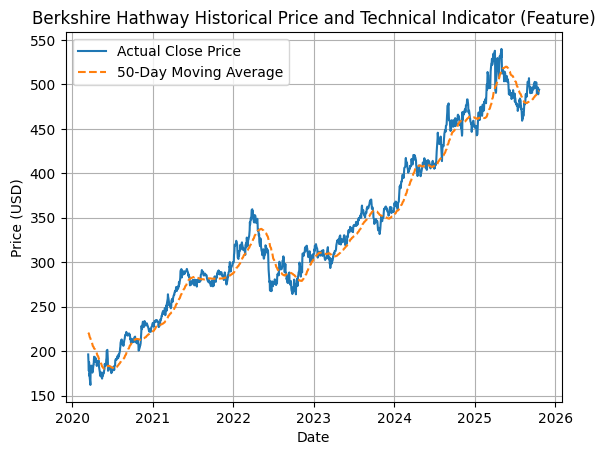

In [38]:
plt.Figure(figsize=(12,6))
# Plot the actual closing price over time
plt.plot(df.index,df["Close"],label="Actual Close Price")
# Plot the 50-day Simple Moving Average (SMA) as a context feature
plt.plot(df.index,df["SMA_50"],label="50-Day Moving Average",linestyle="--")
plt.title("Berkshire Hathway Historical Price and Technical Indicator (Feature)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show() # Display the show visualization

Data Splitting

In [39]:
# Split the data into training and testing sets
# We use a time-series split (shuffling is bad for financial data where order matters)
# To maintain the time order, we use the standard array slicing
test_size=0.2 # 20% of the data will be used for testing 
test_split_index = int(len(X) - (1 - test_size))

# X_train and y_train are the data used to teach the model (earlier period)
X_train = X[:test_split_index]
y_train = y [:test_split_index]

#  X_test and y_test are the data used to evaluate the model (later period)
X_test = X[test_split_index:]
y_test = y[test_split_index:]

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 1408 samples
Testing set size: 1 samples


Data Scaling

In [40]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler only on the training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
# Apply the *same* transformation to the test data
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easily handling (optional but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

Model Definition, Hyperparameter Tuning and Training

In [43]:
# Dictionary to hold all models (Linear Regression has no hyperparameters to tune here)
models = {
    "Linear Regression" : LinearRegression()
}

# Hyperparameter Tuning using GridSearchCV

# Ridge Regression (L2 Regularization)
#  Define the grid of alpha values to search (alpha controls the strength of regularization)
ridge_params = {
    "alpha": [0.1,1.0,10.0,100.0]
}
# Initialize GridSearchCV for Ridge
ridge_gs = GridSearchCV(Ridge(),ridge_params,cv=5,scoring="neg_mean_squared_error")
print("----- Tuning Ridge Regression -----")
# Fit the GridSearchCV object to the scaled training data
ridge_gs.fit(X_train_scaled,y_train)
# Add the best estimator (the tuned model) to our models accuracy
models["Ridge"] = ridge_gs.best_estimator_
print(f"Best Ridge Alpha: {ridge_gs.best_params_["alpha"]}")

# Lasso Regression (L1 Regularization)
# Define the grid of alpha values to search
lasso_params = {
    "alpha":[0.001,0.01,0.1,1.0]
}
# Initialize the GridSearchCV for Lasso
lasso_gs = GridSearchCV(Lasso(max_iter=5000),lasso_params,cv=5,scoring="neg_mean_squared_error")
print("----- Tuning Lasso Regression -----")
# Fit the GridSearchCV object
lasso_gs.fit(X_train_scaled,y_train)
# Add the best estimator to our models dictionary
models["Lasso"] = lasso_gs.best_estimator_
print(f"Best Lasso Alpha: {lasso_gs.best_params_["alpha"]}")

# Support the Vector Regression (SVR)
# Define the grid of parameters to search (C for regularization, gamma for kernel influence)
svr_params = {
    "C":[0.1,1,10],
    "gamma":["scale","auto"]
}
# Initialize the GridSearchCV for SVR (using a Radial Basis Fucntion kernel by default)
svr_gs = GridSearchCV(SVR(kernel="rbf"),svr_params,cv=3,scoring="neg_mean_squared_error")
print("----- Tuning SVR -----")
# Fit the GridSearch object
svr_gs.fit(X_train_scaled,y_train)
# Add the best estimator to our models dictionary
models["SVR"] = svr_gs.best_estimator_
print(f"Best SVR Params: {svr_gs.best_params_}")

----- Tuning Ridge Regression -----
Best Ridge Alpha: 0.1
----- Tuning Lasso Regression -----


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.064e+03, tolerance: 7.069e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.036e+04, tolerance: 1.201e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

Best Lasso Alpha: 0.001
----- Tuning SVR -----
Best SVR Params: {'C': 10, 'gamma': 'auto'}


In [44]:
# Training and Initial Prediction (Linear Regression Only)
# Note: Ridge,Lasso and SVR are already trained via GridSearchCV

# Train the standard Linear Regression model (which wasn't tuned)
print("'----- Training Linear Regression -----")
models["Linear Regression"].fit(X_train_scaled,y_train)

# Dictionary to store performance metrics
performance = {}

'----- Training Linear Regression -----


Model Evaluation and Comparison

In [53]:
# Iterate through all trained models to evaluate their performance on the test set
for name, model in models.items():
    # Make predictions on the scaled test data
    y_pred = model.predict(X_test_scaled)

    # Calculate the evaluation metrics
    # Root Mean Squared Error (RMSE): Square root of the average squared differences. Penalty for large errors
    rmse = np.sqrt(mean_absolute_error(y_test,y_pred))
    # Mean Absolute Error (MAE): Average absolute difference. Easier to interpret in dollars
    mae = mean_absolute_error(y_test,y_pred)
    # R-squared (R2): Proportion of the variance in the dependent variable explained by the model
    r2 = r2_score(y_test,y_pred)

    # Store the metrics
    performance[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
  

    # Print the results for comparison
    print(f"{name} Results")
    print(f"R-squared  (R2): {r2:.4f}")
    print(f"Mean Absolute Error(MAE): ${mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")


# Convert the peformance dictionary into a DataFrame for easy viewing and sorting
performance_df = pd.DataFrame(performance).T

# Sort the DataFrame to find the best model based on R2 (higher is better)
best_model_name =performance_df["R2"].max()
best_model = models[best_model_name]



print("=" * 50)
print(f"The Best Performing Model is: {best_model_name}")
print(f"With R2: {performance_df["R2"].max():.4f}")
print("="*50)
print("Comparative Performance Table (Sortedby R2):")
print(performance_df.sort_values(by="R2",ascending=False))

Linear Regression Results
R-squared  (R2): nan
Mean Absolute Error(MAE): $1.25
Root Mean Squared Error (RMSE): $1.12
Ridge Results
R-squared  (R2): nan
Mean Absolute Error(MAE): $1.18
Root Mean Squared Error (RMSE): $1.09
Lasso Results
R-squared  (R2): nan
Mean Absolute Error(MAE): $1.08
Root Mean Squared Error (RMSE): $1.04
SVR Results
R-squared  (R2): nan
Mean Absolute Error(MAE): $0.55
Root Mean Squared Error (RMSE): $0.74


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


KeyError: np.float64(nan)

Visualization After Training

In [ ]:
# Create a DataFrame to hold actual and predicted values for plotting
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': best_model_predictions}, index=X_test.index)

plt.figure(figsize=(14, 7))
# Plot the actual closing prices from the test set
plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual Closing Price (Test Set)', color='blue')
# Plot the predicted closing prices from the best model
plt.plot(predictions_df.index, predictions_df['Predicted'], label=f'{best_model_name} Predictions', color='red', linestyle='--')

plt.title(f'Actual vs. Predicted Stock Price ({TICKER}) - Best Model: {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show() # Display the post-training visualization